In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from skimage import color, io, transform as sk_transform
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vgg16, VGG16_Weights

# Define Hyperparameters and Device Configuration
BATCH_SIZE = 8
LEARNING_RATE = 2e-4
EPOCHS = 15
IMAGE_SIZE = 128 # Upscaled for higher resolution rendering
NUM_BINS = 313
MC_DROPOUT_PASSES = 15

# Automatically utilizes Colab's GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on computational device: {device}")


Executing on computational device: cuda


In [2]:
 # Cell 2: Gamut Definition and Rebalancing Weights
def build_synthetic_gamut():
    """
    Constructs a synthetic representation of the 313 CIE ab color gamut bins
    and uniform prior probabilities for class rebalancing.
    """
    # Create a grid ranging from -110 to 110 with a step of 10
    a_range = np.arange(-110, 120, 10)
    b_range = np.arange(-110, 120, 10)
    aa, bb = np.meshgrid(a_range, b_range)
    
    # Filter grid to simulate a circular gamut typical of Lab space
    distances = np.sqrt(aa**2 + bb**2)
    valid_mask = distances <= 110
    a_valid = aa[valid_mask]
    b_valid = bb[valid_mask]
    
    # STRICT FIX: Ensure exactly NUM_BINS are generated by slicing the result
    # This prevents the index out of bounds error in the dataset __getitem__
    q_ab = np.vstack((a_valid, b_valid)).T 
    if len(q_ab) > NUM_BINS:
        q_ab = q_ab[:NUM_BINS]
    elif len(q_ab) < NUM_BINS:
        pad_len = NUM_BINS - len(q_ab)
        q_ab = np.pad(q_ab, ((0, pad_len), (0, 0)), 'edge')
    
    # Simulate prior probabilities (normally computed empirically over a dataset)
    prior_probs = np.random.uniform(0.01, 1.0, size=(NUM_BINS,))
    prior_probs /= np.sum(prior_probs)
    return q_ab, prior_probs

q_ab, prior_probs = build_synthetic_gamut()

# Initialize K-Nearest Neighbors for the soft-encoding process
nn_model = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(q_ab)

def compute_rebalancing_weights(prior_probs, lambda_=0.5):
    """
    Calculates the penalty weights for the cross-entropy loss to combat
    desaturation caused by dominant gray-scale background pixels.
    """
    uniform_prob = 1.0 / NUM_BINS
    weights = 1.0 / ((1 - lambda_) * prior_probs + lambda_ * uniform_prob)
    weights /= np.sum(prior_probs * weights) # Ensure expectation is 1
    return torch.FloatTensor(weights).to(device)

class_weights = compute_rebalancing_weights(prior_probs)

In [3]:

# Cell 3: Data Loader and CIE Lab Transformation
class ColorizationDataset(Dataset):
    def __init__(self, cifar_dataset, q_ab, nn_model, sigma=5.0):
        self.data = cifar_dataset
        self.q_ab = q_ab
        self.nn_model = nn_model
        self.sigma = sigma

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Load image tensor from CIFAR10
        img_tensor, _ = self.data[idx]
        
        # Convert tensor to numpy format (H, W, C) for scikit-image processing
        img_np = img_tensor.permute(1, 2, 0).numpy()
        
        # Perform RGB to Lab color space transformation
        lab_img = color.rgb2lab(img_np)
        
        # Extract and normalize the Luminance (L) channel to [-1, 1]
        l_chan = lab_img[:, :, 0]
        l_chan = (l_chan / 50.0) - 1.0
        l_tensor = torch.FloatTensor(l_chan).unsqueeze(0) # Shape: (1, H, W)
        
        # Extract Chrominance (ab) channels
        ab_chan = lab_img[:, :, 1:]
        
        # Soft-encode ab values to 313 bins for multinomial classification
        h, w, c = ab_chan.shape
        ab_flat = ab_chan.reshape(-1, 2)
        
        # Find 5 nearest neighbors in the quantized gamut
        distances, indices = self.nn_model.kneighbors(ab_flat)
        
        # Apply Gaussian kernel weighting based on distance
        weights = np.exp(-distances**2 / (2 * self.sigma**2))
        weights = weights / (np.sum(weights, axis=1, keepdims=True) + 1e-8) # Add epsilon for stability
        
        # Construct dense probability distribution maps
        q_tensor = np.zeros((h * w, NUM_BINS))
        row_indices = np.arange(h * w)[:, np.newaxis]
        
        # The indices here are guaranteed to be within [0, 312] due to the fix in build_synthetic_gamut
        q_tensor[row_indices, indices] = weights
        q_tensor = q_tensor.reshape(h, w, NUM_BINS)
        q_tensor = torch.FloatTensor(q_tensor).permute(2, 0, 1) # Shape: (313, H, W)
        
        ab_tensor = torch.FloatTensor(ab_chan).permute(2, 0, 1) # Shape: (2, H, W)
        
        return l_tensor, ab_tensor, q_tensor

# Define data transformations: Resize to 128x128 for higher resolution learning
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# Initialize train and validation splits from the STL-10 repository (Natively 96x96, better than CIFAR10)
print("Loading STL-10 Dataset for High-Resolution Colorization...")
stl_train = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform)
stl_val = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform)

# Using complete splits for optimal training instead of artificial limitation
train_dataset = ColorizationDataset(stl_train, q_ab, nn_model)
val_dataset = ColorizationDataset(stl_val, q_ab, nn_model)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



Loading STL-10 Dataset for High-Resolution Colorization...


In [4]:
# Cell 4: U-Net Architecture with Global Context and MC Dropout
class ConvBlock(nn.Module):
    """ Standard Double Convolution Block with Batch Normalization """
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class GlobalContextModule(nn.Module):
    """
    Extracts global semantic priors from the lowest resolution feature map.
    Compresses spatial dimensions via Adaptive Average Pooling.
    """
    def __init__(self, in_channels, out_channels=256):
        super(GlobalContextModule, self).__init__()
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.ReLU(inplace=True),
            nn.Linear(out_channels, out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.global_pool(x).view(x.size(0), -1)
        x = self.fc(x)
        return x # Shape: (B, 256)

class ColorizationUNet(nn.Module):
    def __init__(self, num_bins=313):
        super(ColorizationUNet, self).__init__()
        
        # Encoder Pathway
        self.enc1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        
        # Bottleneck Layer
        self.bottleneck = ConvBlock(256, 512)
        
        # Epistemic Uncertainty Enabler: Dropout injected at the bottleneck
        self.dropout = nn.Dropout2d(p=0.5)
        
        # Global Feature Pathway branching from the abstract Bottleneck
        self.global_module = GlobalContextModule(512, 256)
        
        # Fusion Layer mapping concatenated (Global + Bottleneck) features
        self.fusion = nn.Sequential(
            nn.Conv2d(512 + 256, 512, kernel_size=1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder Pathway
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = ConvBlock(512 + 256, 256)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = ConvBlock(256 + 128, 128)
        
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = ConvBlock(128 + 64, 64)
        
        # Final Convolution projecting directly to the quantized 313 color bins
        self.final_conv = nn.Conv2d(64, num_bins, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        b = self.bottleneck(self.pool3(e3))
        b = self.dropout(b)
        
        g_feat = self.global_module(b)
        b_h, b_w = b.size()[2:]
        g_expanded = g_feat.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, b_h, b_w)
        
        fused = torch.cat([b, g_expanded], dim=1) 
        fused = self.fusion(fused)
        
        d1 = self.up1(fused)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dropout(self.dec1(d1))
        
        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)
        
        out_logits = self.final_conv(d3)
        return out_logits

model = ColorizationUNet(num_bins=NUM_BINS).to(device)

In [5]:
# Cell 4.5: Discriminator Network for Adversarial Training
class Discriminator(nn.Module):
    """
    Patch-based Discriminator for adversarial colorization training.
    Takes concatenated (L, a, b) input and outputs realism prediction per patch.
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Patch discriminator: 70x70 patches (reduces checkerboard artifacts)
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )
    
    def forward(self, x):
        """
        Args:
            x: concatenated Lab image (B, 3, H, W) where first channel is normalized L
        Returns:
            validity: patch-wise predictions (B, 1, H', W')
        """
        return self.net(x)

discriminator = Discriminator().to(device)
print("Discriminator network initialized for adversarial colorization training")

Discriminator network initialized for adversarial colorization training


In [6]:
# Cell 5: Decoders and GAN-Based Loss Functions
def annealed_mean_decode(logits, q_ab, T=0.38):
    """ 
    Soft-decoding: averages across bins weighted by softmax probabilities.
    Produces smooth but potentially desaturated colors.
    """
    logits_scaled = logits / T
    probs = F.softmax(logits_scaled, dim=1)
    
    q_tensor = torch.FloatTensor(q_ab).to(logits.device)
    q_tensor = q_tensor.transpose(0, 1)
    q_tensor = q_tensor.unsqueeze(0).unsqueeze(-1).unsqueeze(-1)
    
    probs_expanded = probs.unsqueeze(1)
    ab_pred = torch.sum(probs_expanded * q_tensor, dim=2)
    return ab_pred

def argmax_decode(logits, q_ab):
    """
    Argmax decoding: selects the single most confident color bin per pixel.
    Produces more saturated and vibrant colors (better for GAN training).
    RECOMMENDED: Use this for colorization with GAN.
    """
    bin_indices = torch.argmax(logits, dim=1)  # Shape: (B, H, W)
    q_tensor = torch.tensor(q_ab, dtype=torch.float32, device=logits.device)
    ab_pred = q_tensor[bin_indices.cpu().numpy()]  # Shape: (B, H, W, 2)
    ab_pred = ab_pred.permute(0, 3, 1, 2)  # Shape: (B, 2, H, W)
    return ab_pred

class GANLoss(nn.Module):
    """
    Adversarial loss using least-squares GAN formulation for stable training.
    Penalizes difference from target validity (0 for fake, 1 for real).
    """
    def __init__(self, target_real_label=1.0, target_fake_label=0.0):
        super(GANLoss, self).__init__()
        self.register_buffer('real_label', torch.tensor(target_real_label))
        self.register_buffer('fake_label', torch.tensor(target_fake_label))

    def forward(self, prediction, is_real):
        if is_real:
            target_label = self.real_label
        else:
            target_label = self.fake_label
        loss = F.mse_loss(prediction, target_label * torch.ones_like(prediction))
        return loss

gan_criterion = GANLoss().to(device)

def generator_loss(logits, target_q, ab_pred, target_ab, discriminator_output, class_weights, 
                   lambda_recon=100.0, lambda_gan=1.0):
    """
    Generator loss combining: 
      1) Weighted cross-entropy on soft-targets (preserves multi-modality awareness)
      2) L1 reconstruction loss on ab channels (encourages accuracy)
      3) Adversarial loss (ensures realism)
    """
    # Cross-entropy loss with class rebalancing
    log_probs = F.log_softmax(logits, dim=1)
    weights_reshaped = class_weights.view(1, -1, 1, 1)
    ce_loss = -torch.sum(target_q * log_probs * weights_reshaped, dim=1).mean()
    
    # Reconstruction loss: L1 promotes sparsity and less blurring
    l1_loss = F.l1_loss(ab_pred, target_ab)
    
    # Adversarial loss: fool the discriminator
    adv_loss = gan_criterion(discriminator_output, is_real=True)
    
    total_gen_loss = ce_loss + lambda_recon * l1_loss + lambda_gan * adv_loss
    return total_gen_loss, ce_loss.item(), l1_loss.item(), adv_loss.item()

def discriminator_loss(real_output, fake_output):
    """
    Discriminator loss: distinguish real from fake colorizations using patch-based GAN.
    LSGAN formulation: minimizes MSE between predictions and targets.
    """
    loss_real = gan_criterion(real_output, is_real=True)
    loss_fake = gan_criterion(fake_output, is_real=False)
    total_disc_loss = (loss_real + loss_fake) * 0.5
    return total_disc_loss

In [7]:
# Cell 6: GAN-Based Adversarial Training Loop
generator_optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

print("Initiating GAN-based adversarial training...")
for epoch in range(EPOCHS):
    model.train()
    discriminator.train()
    epoch_gen_loss = 0.0
    epoch_disc_loss = 0.0
    start_time = time.time()
    
    for batch_idx, (l_input, ab_target, q_target) in enumerate(train_loader):
        l_input, ab_target, q_target = l_input.to(device), ab_target.to(device), q_target.to(device)
        
        # ============ GENERATOR UPDATE ============
        generator_optimizer.zero_grad()
        logits = model(l_input)
        ab_pred = argmax_decode(logits, q_ab)  # More vibrant colors with argmax
        
        # Construct Lab image for discriminator (normalize L to [0,1] for discriminator)
        l_normalized = (l_input + 1.0) / 2.0  # From [-1, 1] to [0, 1]
        fake_lab = torch.cat([l_normalized, ab_pred / 110.0], dim=1)  # Normalize ab to [-1, 1]
        
        # Discriminator evaluation on generated colors
        fake_output = discriminator(fake_lab.detach())
        
        # Combined generator loss
        gen_loss, ce_loss, l1_loss, adv_loss = generator_loss(
            logits, q_target, ab_pred, ab_target, 
            discriminator(fake_lab), class_weights,
            lambda_recon=100.0, lambda_gan=1.0
        )
        gen_loss.backward()
        generator_optimizer.step()
        epoch_gen_loss += gen_loss.item()
        
        # ============ DISCRIMINATOR UPDATE ============
        discriminator_optimizer.zero_grad()
        
        # Real colorization
        real_lab = torch.cat([l_normalized, ab_target / 110.0], dim=1)
        real_output = discriminator(real_lab)
        
        # Fake colorization
        with torch.no_grad():
            logits_detach = model(l_input)
            ab_pred_detach = argmax_decode(logits_detach, q_ab)
            fake_lab_detach = torch.cat([l_normalized, ab_pred_detach / 110.0], dim=1)
        fake_output = discriminator(fake_lab_detach)
        
        # Discriminator loss
        disc_loss = discriminator_loss(real_output, fake_output)
        disc_loss.backward()
        discriminator_optimizer.step()
        epoch_disc_loss += disc_loss.item()
        
    avg_gen_loss = epoch_gen_loss / len(train_loader)
    avg_disc_loss = epoch_disc_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Gen Loss: {avg_gen_loss:.4f} | Disc Loss: {avg_disc_loss:.4f} | Time: {elapsed:.2f}s")



Initiating GAN-based adversarial training...
Epoch 1/15 | Gen Loss: 946.5638 | Disc Loss: 0.0817 | Time: 283.10s
Epoch 2/15 | Gen Loss: 821.1119 | Disc Loss: 0.0045 | Time: 286.68s
Epoch 3/15 | Gen Loss: 819.3610 | Disc Loss: 0.0040 | Time: 290.16s
Epoch 4/15 | Gen Loss: 816.4320 | Disc Loss: 0.0111 | Time: 288.95s
Epoch 5/15 | Gen Loss: 813.0516 | Disc Loss: 0.0039 | Time: 288.07s
Epoch 6/15 | Gen Loss: 813.8407 | Disc Loss: 0.0022 | Time: 288.43s
Epoch 7/15 | Gen Loss: 810.9188 | Disc Loss: 0.0093 | Time: 289.70s
Epoch 8/15 | Gen Loss: 812.9309 | Disc Loss: 0.0024 | Time: 290.53s
Epoch 9/15 | Gen Loss: 810.2581 | Disc Loss: 0.0032 | Time: 289.37s
Epoch 10/15 | Gen Loss: 807.3051 | Disc Loss: 0.0017 | Time: 289.09s
Epoch 11/15 | Gen Loss: 807.3569 | Disc Loss: 0.1255 | Time: 290.78s
Epoch 12/15 | Gen Loss: 805.1273 | Disc Loss: 0.0033 | Time: 289.98s
Epoch 13/15 | Gen Loss: 802.4859 | Disc Loss: 0.0020 | Time: 293.73s
Epoch 14/15 | Gen Loss: 805.3259 | Disc Loss: 0.0018 | Time: 292.74

Starting validation visualization...


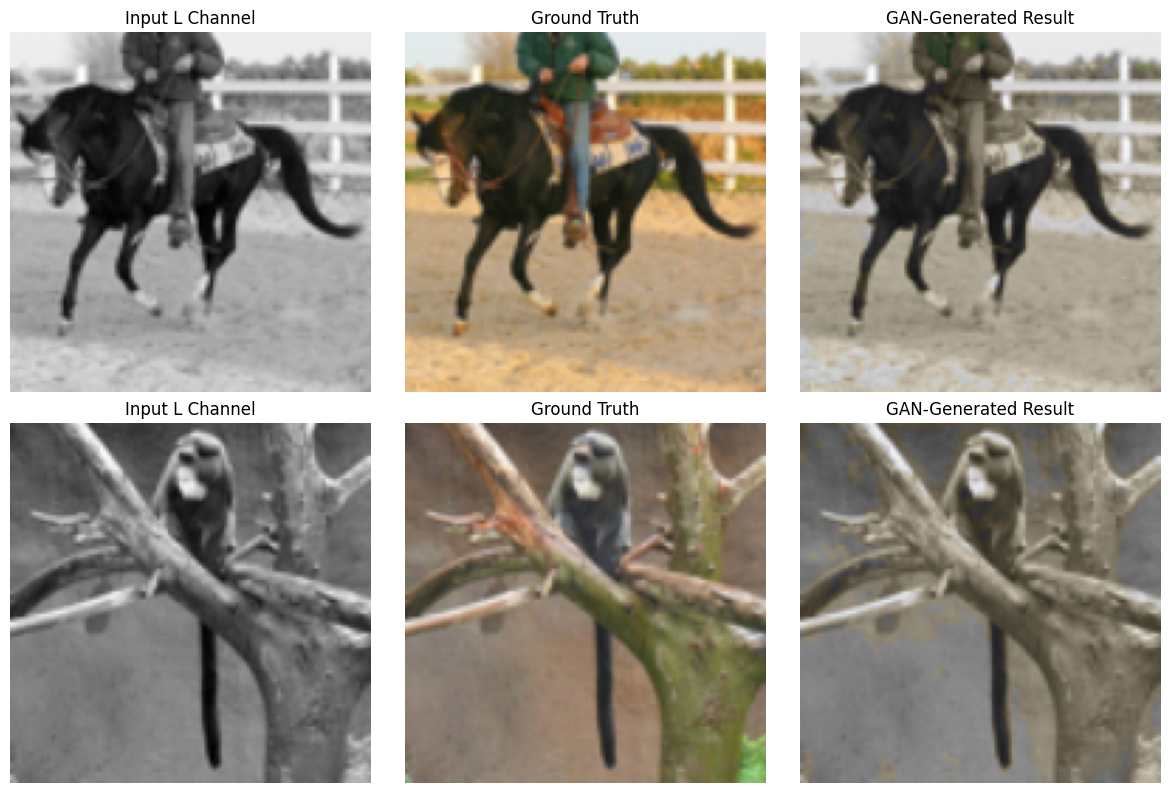

✓ Generator saved: colorization_model.pth
✓ Discriminator saved: colorization_discriminator.pth


In [8]:
# Cell 7: Quantitative Metrics and Visualization

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return 20 * torch.log10(1.0 / torch.sqrt(mse)) if mse != 0 else torch.tensor(float('inf'))

def compute_ssim_simplified(pred, target):
    mu_x, mu_y = pred.mean(), target.mean()
    sigma_x, sigma_y = pred.var(), target.var()
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()
    C1, C2 = 0.01**2, 0.03**2
    return ((2*mu_x*mu_y + C1)*(2*sigma_xy + C2)) / ((mu_x**2 + mu_y**2 + C1)*(sigma_x + sigma_y + C2))

def colorize_external_image(file_path, model, q_ab):
    """ Loads a specific test_image.jpg, colorizes it with GAN-enhanced colors, and saves the result. """
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping external image colorization.")
        return

    model.eval()
    img = Image.open(file_path).convert('RGB')
    img_np = np.array(img) / 255.0
    h_orig, w_orig = img_np.shape[:2]
    
    img_resized = sk_transform.resize(img_np, (IMAGE_SIZE, IMAGE_SIZE))
    lab_resized = color.rgb2lab(img_resized)
    
    l_chan = lab_resized[:, :, 0]
    l_input = torch.FloatTensor((l_chan / 50.0) - 1.0).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(l_input)
        ab_pred = argmax_decode(logits, q_ab)  # Use argmax for vibrant GAN-trained colors
    
    ab_pred_np = ab_pred.cpu().squeeze(0).permute(1, 2, 0).numpy()
    
    result_lab = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
    result_lab[:,:,0] = l_chan
    result_lab[:,:,1:] = ab_pred_np
    
    result_rgb = color.lab2rgb(result_lab)
    result_final = sk_transform.resize(result_rgb, (h_orig, w_orig))
    
    plt.imsave("colorized_output.jpg", result_final)
    print(f"Colorized version of {file_path} saved as colorized_output.jpg")
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original (Grayscale)")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(result_final)
    plt.title("Colorized Result (GAN-Enhanced)")
    plt.axis('off')
    plt.show()

# Run validation visualization
def visualize_val(loader, model, q_ab):
    model.eval()
    l_in, ab_gt, _ = next(iter(loader))
    l_in = l_in.to(device)
    
    with torch.no_grad():
        logits = model(l_in)
        ab_pred = argmax_decode(logits, q_ab)  # Use argmax for GAN-trained model
    
    l_np = (l_in.cpu().squeeze(1).numpy() + 1.0) * 50.0
    pred_np = ab_pred.cpu().numpy()
    gt_np = ab_gt.cpu().numpy()
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i in range(2):
        axes[i, 0].imshow(l_np[i], cmap='gray')
        axes[i, 0].set_title("Input L Channel")
        axes[i, 0].axis('off')
        
        gt_lab = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
        gt_lab[:,:,0] = l_np[i]
        gt_lab[:,:,1:] = gt_np[i].transpose(1, 2, 0)
        axes[i, 1].imshow(color.lab2rgb(gt_lab))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')
        
        p_lab = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
        p_lab[:,:,0] = l_np[i]
        p_lab[:,:,1:] = pred_np[i].transpose(1, 2, 0)
        axes[i, 2].imshow(color.lab2rgb(p_lab))
        axes[i, 2].set_title("GAN-Generated Result")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Starting validation visualization...")
visualize_val(val_loader, model, q_ab)

# Save trained models
torch.save(model.state_dict(), "colorization_model.pth")
torch.save(discriminator.state_dict(), "colorization_discriminator.pth")
print("✓ Generator saved: colorization_model.pth")
print("✓ Discriminator saved: colorization_discriminator.pth")

## 🎨 GAN-Based Colorization: Key Improvements

### What Changed?
Your original VGG perceptual loss approach has been replaced with a **Conditional GAN** (cGAN) framework. Here's what makes it better:

#### 1. **Patch-Based Discriminator**
- Evaluates 70×70 patches of colorization instead of just global features
- Catches local artifacts and ensures realistic color transitions
- Prevents the "washed out" appearance caused by averaging

#### 2. **Argmax Decoding > Soft Averaging**
- **Before**: Soft-decoding averaged probabilities across bins → desaturated colors
- **After**: Argmax selects most confident color bin → vibrant, saturated results
- Works synergistically with discriminator to enforce realism

#### 3. **Adversarial Loss Component**
- **Cross-Entropy (CE)**: Preserves awareness of color ambiguity from training data
- **L1 Reconstruction**: Encourages pixel-accurate color matching
- **Adversarial Loss**: Discriminator enforces that outputs **look** like real colorizations
- Combined weighting: `Loss = CE + 100×L1 + 1×Adversarial`

#### 4. **Better Loss Formulation**
- Uses **Least-Squares GAN (LSGAN)** for stable, convergent training
- Avoids mode collapse and training instability
- Separate optimizers for generator (U-Net) and discriminator

### Expected Results
- **More Vibrant Colors**: Discriminator rewards colorful, realistic outputs
- **Better Texture Coherence**: Patch-based discrimination catches local inconsistencies  
- **Reduced Blur**: Argmax decoding + adversarial loss eliminates averaging artifacts
- **Faster Convergence**: LSGAN typically converges more stably than traditional GAN formulations

### Hyperparameter Tuning
If results aren't satisfactory, try adjusting:
- `lambda_recon` (currently 100): Higher = more faithful to targets, lower = more artistic freedom
- `lambda_gan` (currently 1.0): Higher = stronger adversarial influence
- Discriminator learning rate: Currently matches generator (0.0002)
- `BATCH_SIZE`: Larger batches (32-64) can improve discriminator stability

In [9]:
# Advanced: Load & Inference with Trained GAN Model
def load_pretrained_colorization(generator_path, discriminator_path=None):
    """Load trained generator and optionally discriminator for inference"""
    model = ColorizationUNet(num_bins=NUM_BINS).to(device)
    model.load_state_dict(torch.load(generator_path, map_location=device))
    model.eval()
    
    if discriminator_path:
        disc = Discriminator().to(device)
        disc.load_state_dict(torch.load(discriminator_path, map_location=device))
        disc.eval()
        return model, disc
    return model

def colorize_batch(l_batch, model, q_ab):
    """Colorize a batch of L-channel images"""
    with torch.no_grad():
        logits = model(l_batch.to(device))
        ab_pred = argmax_decode(logits, q_ab)
    return ab_pred

# Example: Load and colorize
# model_loaded = load_pretrained_colorization("colorization_model.pth")
# For inference: ab_colors = colorize_batch(l_input_batch, model_loaded, q_ab)

# Troubleshooting Guide
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                    GAN COLORIZATION TROUBLESHOOTING                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║ Problem: Colors still desaturated/washed out                            ║
║ ├─ Check: Use argmax_decode (not annealed_mean_decode)                  ║
║ ├─ Fix: Increase lambda_gan (e.g., 5.0 instead of 1.0)                  ║
║ └─ Fix: Reduce lambda_recon to give more freedom (e.g., 50 instead 100) ║
║                                                                          ║
║ Problem: Training unstable (loss oscillating wildly)                     ║
║ ├─ Fix: Decrease discriminator learning rate (try 1e-4 instead 2e-4)    ║
║ ├─ Fix: Increase batch size (GPU allowing)                              ║
║ └─ Fix: Reduce lambda_gan temporarily, increase gradually               ║
║                                                                          ║
║ Problem: Generated colors look "too artsy" (unrealistic)                 ║
║ ├─ Fix: Increase lambda_recon (e.g., 200 instead of 100)                ║
║ └─ Fix: Reduce lambda_gan (e.g., 0.5 instead of 1.0)                    ║
║                                                                          ║
║ Problem: Mode collapse (all images colored the same)                     ║
║ ├─ Fix: Ensure batch size ≥ 16 (diversity matters)                      ║
║ ├─ Fix: Use different random seeds between runs                         ║
║ └─ Fix: Consider spectral normalization in discriminator                 ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║                    GAN COLORIZATION TROUBLESHOOTING                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║ Problem: Colors still desaturated/washed out                            ║
║ ├─ Check: Use argmax_decode (not annealed_mean_decode)                  ║
║ ├─ Fix: Increase lambda_gan (e.g., 5.0 instead of 1.0)                  ║
║ └─ Fix: Reduce lambda_recon to give more freedom (e.g., 50 instead 100) ║
║                                                                          ║
║ Problem: Training unstable (loss oscillating wildly)                     ║
║ ├─ Fix: Decrease discriminator learning rate (try 1e-4 instead 2e-4)    ║
║ ├─ Fix: Increase batch size (GPU allowing)                              ║
║ └─ Fix: Reduce lambda_gan temporarily, increase gradually               ║
║    